# Milestone 1 - Data Report, EDA & Preprocessing

**Insurance Price Prediction** capstone. Target: `insurance_cost` (regression).

This notebook performs the data report, univariate/bivariate/multivariate EDA, and preprocessing/feature-engineering required by Milestone 1. All reusable logic lives in the `insurance` package so the production pipeline and this notebook stay in sync.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from insurance import config, data
from insurance.features import FeatureEngineer

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
FIG = config.FIGURES_DIR

## 1. Data Report
Import the dataset, inspect shape/size, and review attribute info.

In [2]:
raw = data.load_raw()
print("Shape:", raw.shape)
print("Size :", raw.size)
raw.head()

Shape: (25000, 24)
Size : 600000


,applicant_id,years_of_insurance_with_us,regular_checkup_lasy_year,adventure_sports,Occupation,visited_doctor_last_1_year,cholesterol_level,daily_avg_steps,age,heart_decs_history,other_major_decs_history,Gender,avg_glucose_level,bmi,smoking_status,Year_last_admitted,Location,weight,covered_by_any_other_company,Alcohol,exercise,weight_change_in_last_one_year,fat_percentage,insurance_cost
0,5000,3,1,1,Salried,2,125 to 150,4866,28,1,0,Male,97,31.2,Unknown,NaN,Chennai,67,N,Rare,Moderate,1,25,20978
1,5001,0,0,0,Student,4,150 to 175,6411,50,0,0,Male,212,34.2,formerly smoked,NaN,Jaipur,58,N,Rare,Moderate,3,27,6170
2,5002,1,0,0,Business,4,200 to 225,4509,68,0,0,Female,166,40.4,formerly smoked,NaN,Jaipur,73,N,Daily,Extreme,0,32,28382
3,5003,7,4,0,Business,2,175 to 200,6214,51,0,0,Female,109,22.9,Unknown,NaN,Chennai,71,Y,Rare,No,3,37,27148
4,5004,3,1,0,Student,2,150 to 175,4938,44,0,1,Male,118,26.5,never smoked,2004.0,Bangalore,74,N,No,Extreme,0,34,29616


In [3]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 24 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   applicant_id                    25000 non-null  int64  
 1   years_of_insurance_with_us      25000 non-null  int64  
 2   regular_checkup_lasy_year       25000 non-null  int64  
 3   adventure_sports                25000 non-null  int64  
 4   Occupation                      25000 non-null  object 
 5   visited_doctor_last_1_year      25000 non-null  int64  
 6   cholesterol_level               25000 non-null  object 
 7   daily_avg_steps                 25000 non-null  int64  
 8   age                             25000 non-null  int64  
 9   heart_decs_history              25000 non-null  int64  
 10  other_major_decs_history        25000 non-null  int64  
 11  Gender                          25000 non-null  object 
 12  avg_glucose_level               

### Schema cleanup
The problem statement has typo columns (`regular_checkup_lasy_year`, `heart_decs_history`, `other_major_decs_history`) and a category typo (`Salried`). `clean_schema()` fixes these. `applicant_id` is a unique key with no predictive signal and is dropped during feature engineering.

In [4]:
df = data.load_clean()
data_dict = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "n_unique": df.nunique(),
})
data_dict.to_csv(config.TABLES_DIR / "data_dictionary.csv")
data_dict

,dtype,missing,missing_pct,n_unique
applicant_id,int64,0,0.00,25000
years_of_insurance_with_us,int64,0,0.00,9
regular_checkup_last_year,int64,0,0.00,6
adventure_sports,int64,0,0.00,2
Occupation,object,0,0.00,3
visited_doctor_last_1_year,int64,0,0.00,12
cholesterol_level,object,0,0.00,5
daily_avg_steps,int64,0,0.00,4914
age,int64,0,0.00,59
heart_disease_history,int64,0,0.00,2


**Observation:** 25,000 rows x 24 columns, no duplicate applicant IDs. Only `bmi` (~4%) and `Year_last_admitted` (~47.5%) contain missing values. The high missingness in `Year_last_admitted` is meaningful (no prior admission) rather than random.

## 2. Missing Values

,missing,missing_pct
Year_last_admitted,11881,47.52
bmi,990,3.96


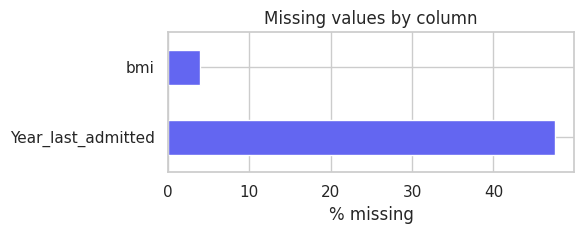

In [5]:
miss = data_dict[data_dict["missing"] > 0][["missing", "missing_pct"]].sort_values("missing", ascending=False)
display(miss)
ax = miss["missing_pct"].plot(kind="barh", color="#6366f1", figsize=(6, 2.5))
ax.set_xlabel("% missing"); ax.set_title("Missing values by column")
plt.tight_layout(); plt.savefig(FIG / "missing_values.png", dpi=120); plt.show()

## 3. Univariate Analysis
### Continuous features

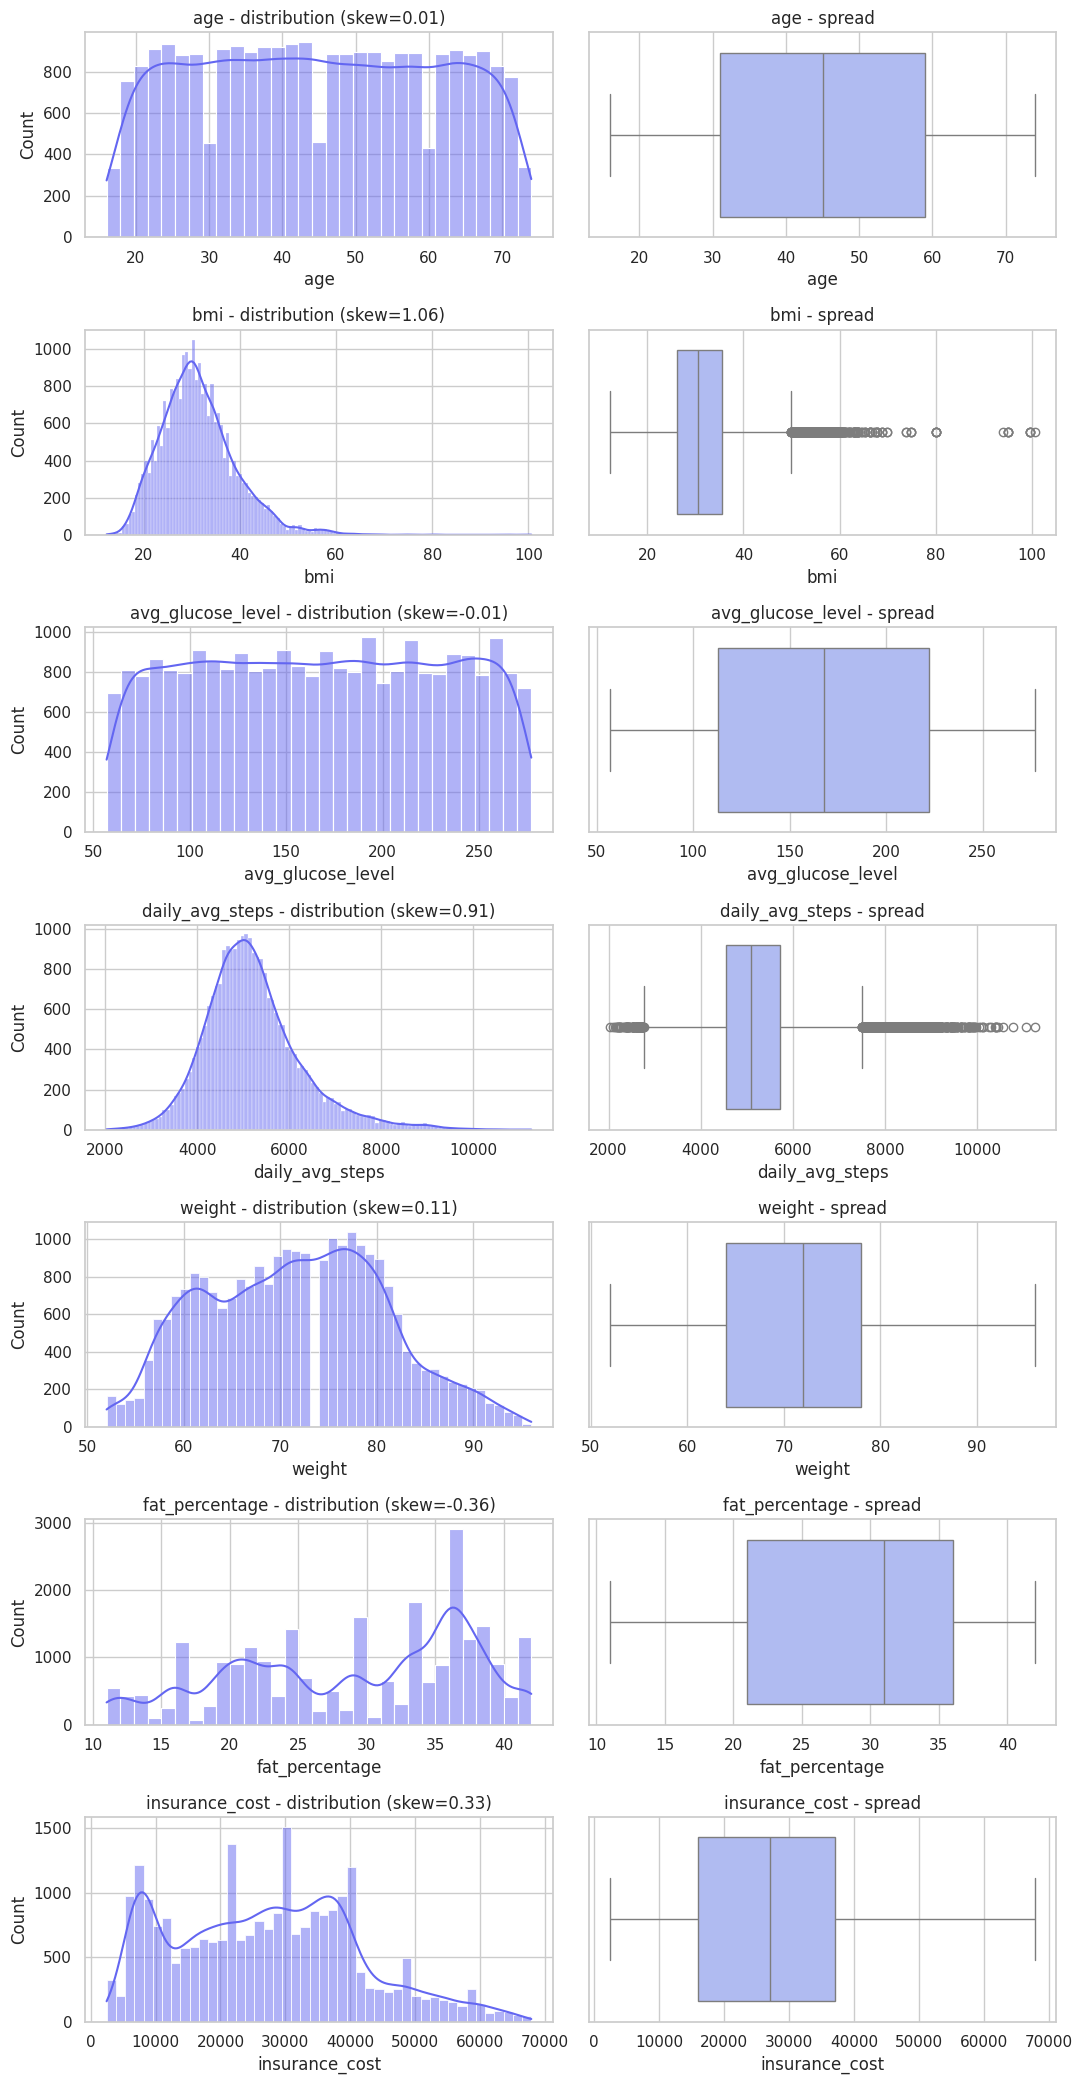

In [6]:
continuous = ["age", "bmi", "avg_glucose_level", "daily_avg_steps", "weight",
              "fat_percentage", "insurance_cost"]
fig, axes = plt.subplots(len(continuous), 2, figsize=(11, 3 * len(continuous)))
for i, col in enumerate(continuous):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i, 0], color="#6366f1")
    axes[i, 0].set_title(f"{col} - distribution (skew={df[col].skew():.2f})")
    sns.boxplot(x=df[col].dropna(), ax=axes[i, 1], color="#a5b4fc")
    axes[i, 1].set_title(f"{col} - spread")
plt.tight_layout(); plt.savefig(FIG / "univariate_continuous.png", dpi=110); plt.show()

**Observation:** `insurance_cost` is mildly right-skewed (~0.33). `bmi`, `weight`, `avg_glucose_level`, and `daily_avg_steps` are roughly symmetric; `daily_avg_steps` and `bmi` show some outliers worth reviewing.

### Categorical features

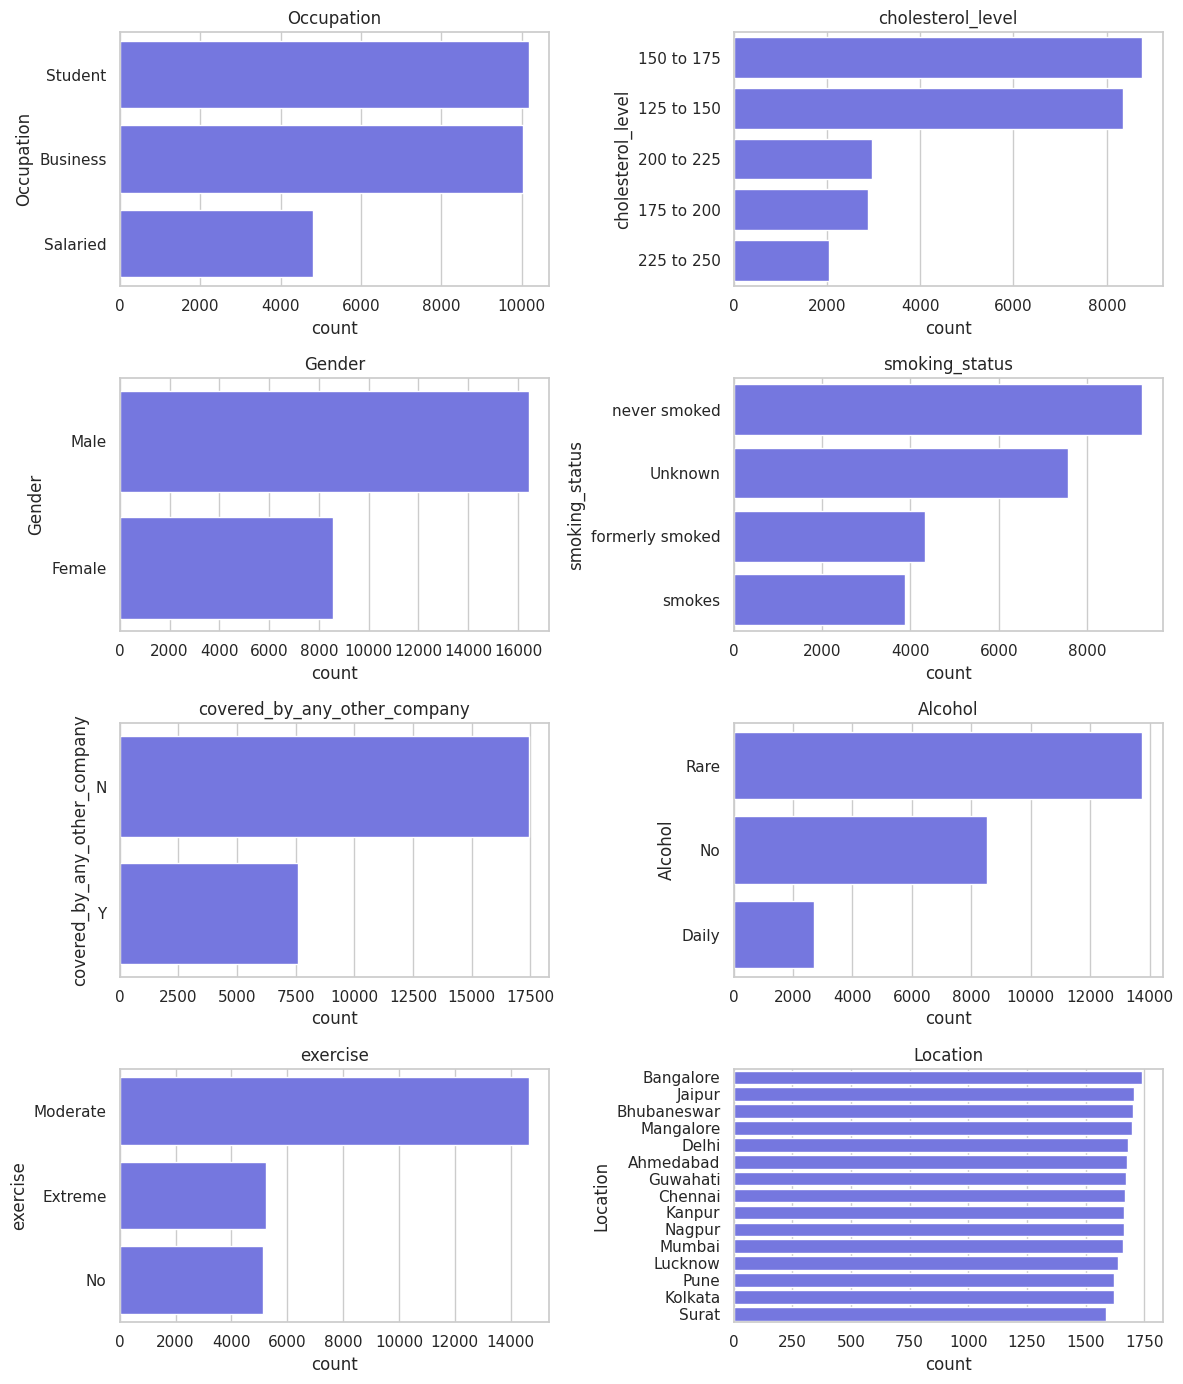

In [7]:
categorical = ["Occupation", "cholesterol_level", "Gender", "smoking_status",
               "covered_by_any_other_company", "Alcohol", "exercise", "Location"]
fig, axes = plt.subplots(4, 2, figsize=(12, 14))
for ax, col in zip(axes.ravel(), categorical):
    order = df[col].value_counts().index
    sns.countplot(y=df[col], order=order, ax=ax, color="#6366f1")
    ax.set_title(col)
plt.tight_layout(); plt.savefig(FIG / "univariate_categorical.png", dpi=110); plt.show()

**Observation:** `Occupation` is dominated by Student/Business (~40% each); Male applicants ~66%; ~30% have `Unknown` smoking status (kept as a valid category); Locations are fairly uniform across 15 cities.

## 4. Bivariate & Multivariate Analysis
### Correlation heatmap

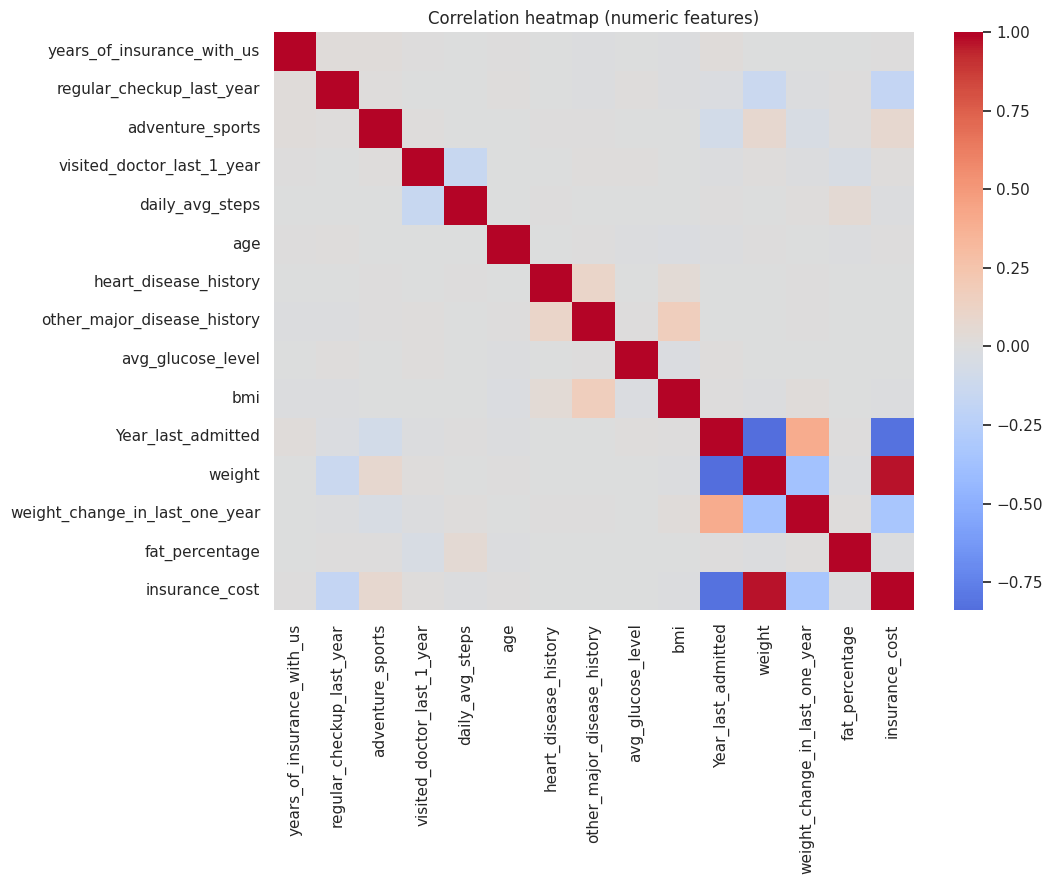

insurance_cost                    1.000000
weight                            0.970357
adventure_sports                  0.074561
visited_doctor_last_1_year        0.008890
age                               0.005195
years_of_insurance_with_us        0.001404
heart_disease_history            -0.000445
other_major_disease_history      -0.002268
avg_glucose_level                -0.005007
daily_avg_steps                  -0.006565
bmi                              -0.008231
fat_percentage                   -0.008486
regular_checkup_last_year        -0.174005
weight_change_in_last_one_year   -0.342710
Year_last_admitted               -0.824137
Name: insurance_cost, dtype: float64

In [8]:
num = df.select_dtypes(include=np.number).drop(columns=[config.ID_COL])
plt.figure(figsize=(11, 9))
sns.heatmap(num.corr(), annot=False, cmap="coolwarm", center=0)
plt.title("Correlation heatmap (numeric features)")
plt.tight_layout(); plt.savefig(FIG / "correlation_heatmap.png", dpi=120); plt.show()
num.corr()["insurance_cost"].sort_values(ascending=False)

**Observation:** `weight` has an unusually strong positive correlation with `insurance_cost` - it dominates the signal. This is flagged for a plausibility / leakage review before any real-world deployment (kept in the model but documented).

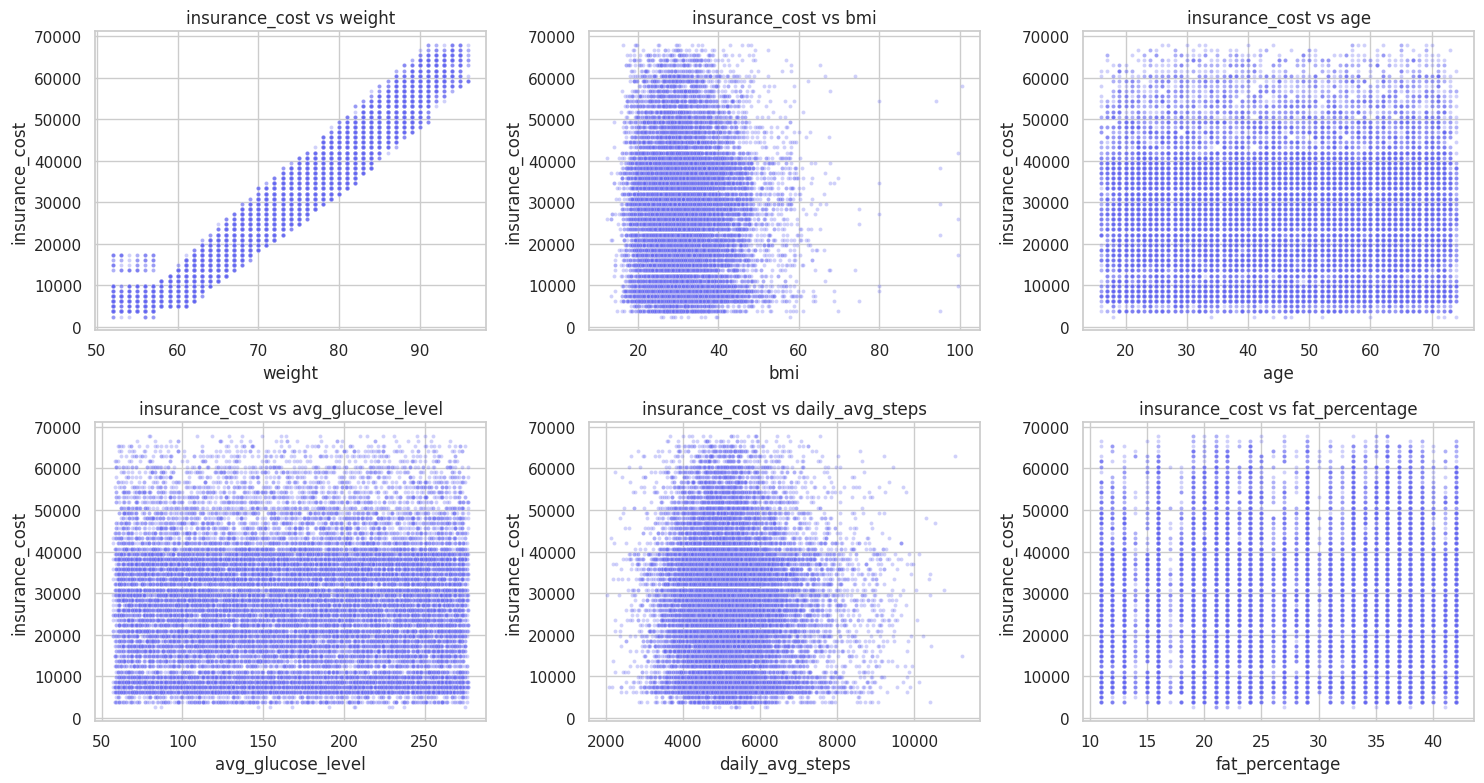

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), ["weight", "bmi", "age", "avg_glucose_level", "daily_avg_steps", "fat_percentage"]):
    sns.scatterplot(x=df[col], y=df["insurance_cost"], s=8, alpha=0.3, ax=ax, color="#6366f1")
    ax.set_title(f"insurance_cost vs {col}")
plt.tight_layout(); plt.savefig(FIG / "scatter_vs_target.png", dpi=110); plt.show()

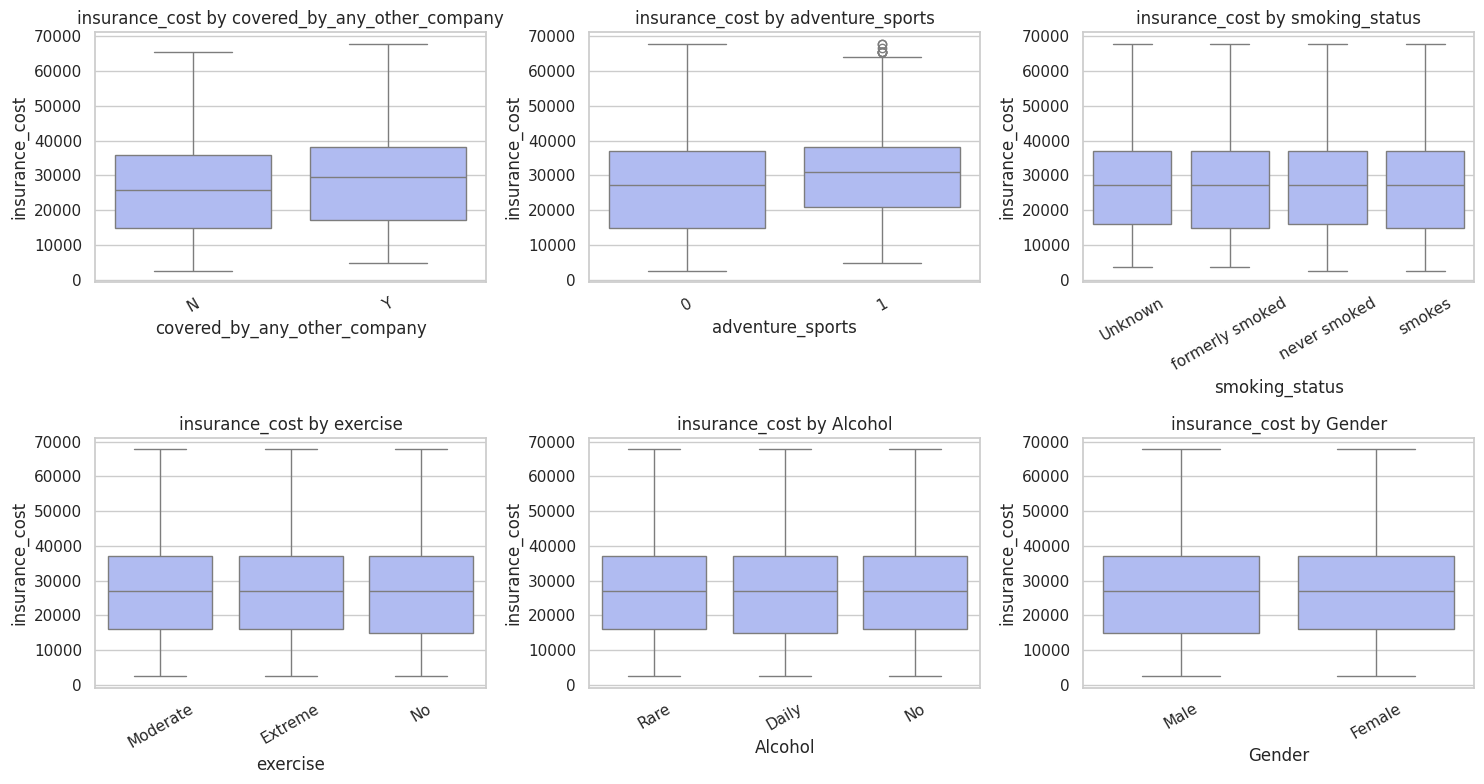

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), ["covered_by_any_other_company", "adventure_sports", "smoking_status", "exercise", "Alcohol", "Gender"]):
    sns.boxplot(x=df[col], y=df["insurance_cost"], ax=ax, color="#a5b4fc")
    ax.set_title(f"insurance_cost by {col}"); ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.savefig(FIG / "boxplots_by_category.png", dpi=110); plt.show()

**Observation:** `covered_by_any_other_company=Y` and `adventure_sports=1` show clearly higher median cost. Lifestyle factors (smoking, alcohol, exercise) have similar medians but can still matter through nonlinear interactions captured by tree models.

## 5. Outlier Review

In [11]:
def iqr_table(frame, cols):
    rows = []
    for c in cols:
        q1, q3 = frame[c].quantile([.25, .75])
        iqr = q3 - q1
        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        out = ((frame[c] < lo) | (frame[c] > hi)).sum()
        rows.append([c, q1, q3, iqr, lo, hi, out, round(out / len(frame) * 100, 2)])
    return pd.DataFrame(rows, columns=["col", "q1", "q3", "iqr", "lower", "upper", "outliers", "pct"])

iqr_table(df, ["bmi", "weight", "avg_glucose_level", "daily_avg_steps", "fat_percentage", "insurance_cost"])

,col,q1,q3,iqr,lower,upper,outliers,pct
0,bmi,26.1,35.6,9.5,11.85,49.85,549,2.20
1,weight,64.0,78.0,14.0,43.00,99.00,0,0.00
2,avg_glucose_level,113.0,222.0,109.0,-50.50,385.50,0,0.00
3,daily_avg_steps,4543.0,5730.0,1187.0,2762.50,7510.50,952,3.81
4,fat_percentage,21.0,36.0,15.0,-1.50,58.50,0,0.00
5,insurance_cost,16042.0,37020.0,20978.0,-15425.00,68487.00,0,0.00


**Treatment:** target outliers are *retained* (high premiums can be valid and business-relevant). `bmi` is capped only at unrealistic extremes (12-60). `daily_avg_steps` outliers are mild and kept; tree models are robust to them.

## 6. Preprocessing & Feature Engineering

In [12]:
print("Duplicate rows:", df.duplicated().sum())
print("Dropping non-predictive id:", config.ID_COL)

fe = FeatureEngineer().fit(df.drop(columns=[config.TARGET]))
engineered = fe.transform(df.drop(columns=[config.TARGET]))
print("Engineered matrix shape:", engineered.shape)
engineered.head()

Duplicate rows: 0
Dropping non-predictive id: applicant_id
Engineered matrix shape: (25000, 28)


,years_of_insurance_with_us,regular_checkup_last_year,visited_doctor_last_1_year,daily_avg_steps,age,avg_glucose_level,bmi,weight,weight_change_in_last_one_year,fat_percentage,adventure_sports,heart_disease_history,other_major_disease_history,cholesterol_midpoint,years_since_last_admitted,was_admitted_before,any_major_disease_history,weight_bmi_interaction,steps_per_age,Occupation,Gender,smoking_status,Location,covered_by_any_other_company,Alcohol,exercise,age_band,bmi_category
0,3,1,2,4866,28,97,31.2,67,1,25,1,1,0,137.5,0.0,0,1,2090.4,173.785714,Salaried,Male,Unknown,Chennai,N,Rare,Moderate,0-29,Obese
1,0,0,4,6411,50,212,34.2,58,3,27,0,0,0,162.5,0.0,0,0,1983.6,128.220000,Student,Male,formerly smoked,Jaipur,N,Rare,Moderate,40-49,Obese
2,1,0,4,4509,68,166,40.4,73,0,32,0,0,0,212.5,0.0,0,0,2949.2,66.308824,Business,Female,formerly smoked,Jaipur,N,Daily,Extreme,60+,Obese
3,7,4,2,6214,51,109,22.9,71,3,37,0,0,0,187.5,0.0,0,0,1625.9,121.843137,Business,Female,Unknown,Chennai,Y,Rare,No,50-59,Normal
4,3,1,2,4938,44,118,26.5,74,0,34,0,0,1,162.5,14.0,1,1,1961.0,112.227273,Student,Male,never smoked,Bangalore,N,No,Extreme,40-49,Overweight


**Engineered features** (in `insurance.features.FeatureEngineer`):
- `age_band`, `bmi_category` - risk bucketing
- `cholesterol_midpoint` - numeric encoding of the cholesterol range
- `was_admitted_before`, `years_since_last_admitted` - derived from `Year_last_admitted` (missing = never admitted)
- `any_major_disease_history` - heart OR other disease
- `weight_bmi_interaction`, `steps_per_age` - interaction/ratio signals

**Missing-value strategy:** `bmi` imputed with the median by (`age_band`, `Gender`) and a global fallback; `Year_last_admitted` re-expressed as the two admission features above.

**Scaling:** numeric columns are standardized inside the production `ColumnTransformer` (`insurance.preprocess`), fit on the training fold only. Required for linear/regularized models, harmless for tree models.

## 7. Advanced EDA
Beyond the basic uni/bivariate views, this section quantifies feature-target relationships with statistical tests and information-theoretic measures, checks multicollinearity, and decomposes the target to expose the *secondary* drivers hidden behind the dominant one.

### 7.1 Target structure - is `insurance_cost` continuous?

Rows: 25000 | unique insurance_cost values: 54

Most frequent cost values:
insurance_cost
7404     1214
38254     977
6170      970
8638      954
37020     869
34552     857
28382     845
35786     827
Name: count, dtype: int64


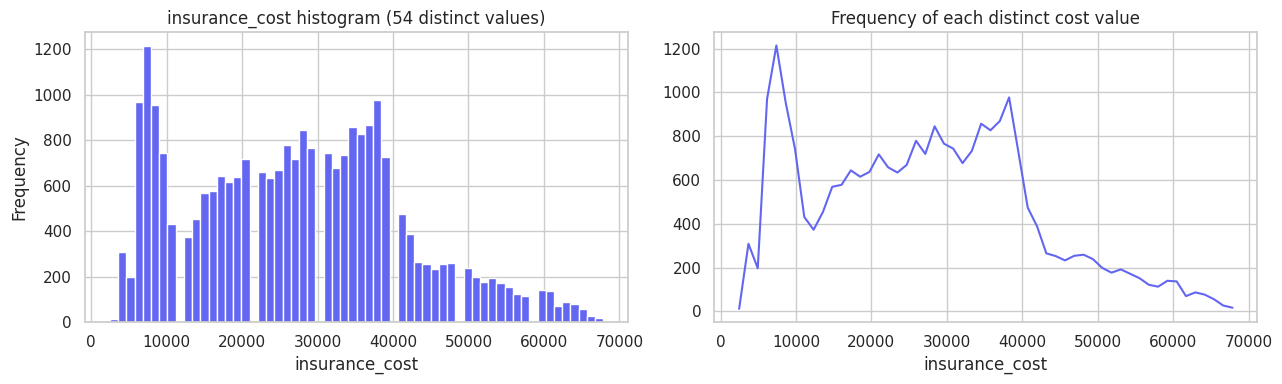

In [13]:
print("Rows:", len(df), "| unique insurance_cost values:", df['insurance_cost'].nunique())
print("\nMost frequent cost values:")
print(df['insurance_cost'].value_counts().head(8))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
df['insurance_cost'].plot(kind='hist', bins=60, ax=ax[0], color="#6366f1")
ax[0].set_title(f"insurance_cost histogram ({df['insurance_cost'].nunique()} distinct values)")
ax[0].set_xlabel("insurance_cost")
df['insurance_cost'].value_counts().sort_index().plot(ax=ax[1], color="#6366f1")
ax[1].set_title("Frequency of each distinct cost value"); ax[1].set_xlabel("insurance_cost")
plt.tight_layout(); plt.savefig(FIG / "target_quantization.png", dpi=120); plt.show()

**Observation:** despite 25,000 rows, `insurance_cost` takes only ~54 distinct values - the target is **quantized** into discrete price levels rather than being smoothly continuous. This strongly suggests cost is generated by a **rule/lookup table** driven by a few inputs, which hints at the dominance of a single predictor seen below.

### 7.2 Correlation with the target - Pearson (linear) vs Spearman (monotonic)

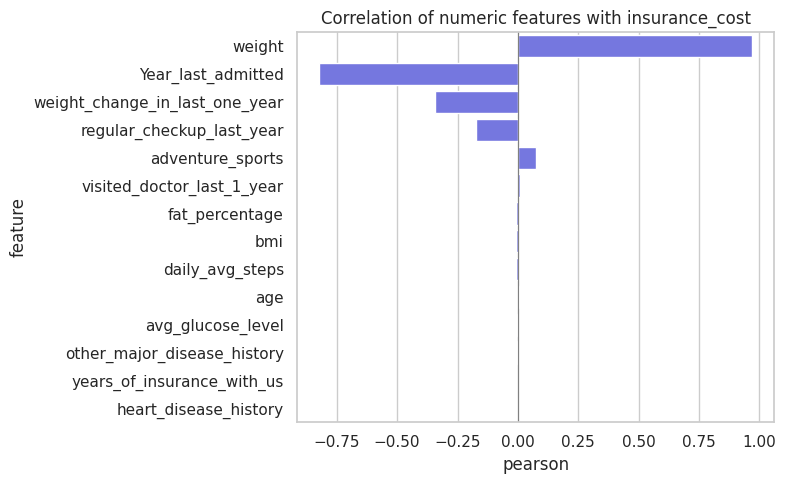

,feature,pearson,spearman
0,weight,0.970,0.972
1,Year_last_admitted,-0.824,-0.846
2,weight_change_in_last_one_year,-0.343,-0.340
3,regular_checkup_last_year,-0.174,-0.169
4,adventure_sports,0.075,0.079
5,visited_doctor_last_1_year,0.009,0.010
6,fat_percentage,-0.008,-0.008
7,bmi,-0.008,-0.009
8,daily_avg_steps,-0.007,-0.007
9,age,0.005,0.005


In [14]:
from scipy.stats import pearsonr, spearmanr

numeric = df.select_dtypes(include=np.number).drop(columns=[config.ID_COL, 'insurance_cost'])
rows = []
for c in numeric.columns:
    valid = df[[c, 'insurance_cost']].dropna()
    rows.append([c, pearsonr(valid[c], valid['insurance_cost'])[0],
                 spearmanr(valid[c], valid['insurance_cost'])[0]])
corr_target = (pd.DataFrame(rows, columns=['feature', 'pearson', 'spearman'])
               .sort_values('pearson', key=lambda s: s.abs(), ascending=False).reset_index(drop=True))

plt.figure(figsize=(8, 5))
sns.barplot(data=corr_target, y='feature', x='pearson', color="#6366f1")
plt.axvline(0, color='grey', lw=0.8); plt.title("Correlation of numeric features with insurance_cost")
plt.tight_layout(); plt.savefig(FIG / "correlation_ranked.png", dpi=120); plt.show()
corr_target.round(3)

**Observation:** `weight` has a near-perfect correlation with cost (Pearson ~ 0.9+), while every other numeric feature is close to zero. Pearson ~ Spearman for `weight`, confirming the relationship is essentially **linear and monotonic** - one feature carries almost all the signal.

### 7.3 `weight` -> `insurance_cost` deep-dive

Simple fit:  cost ~ 1,490 x weight + -79,587
weight-only  r = 0.9704   r2 = 0.9416   (a single-feature linear model)


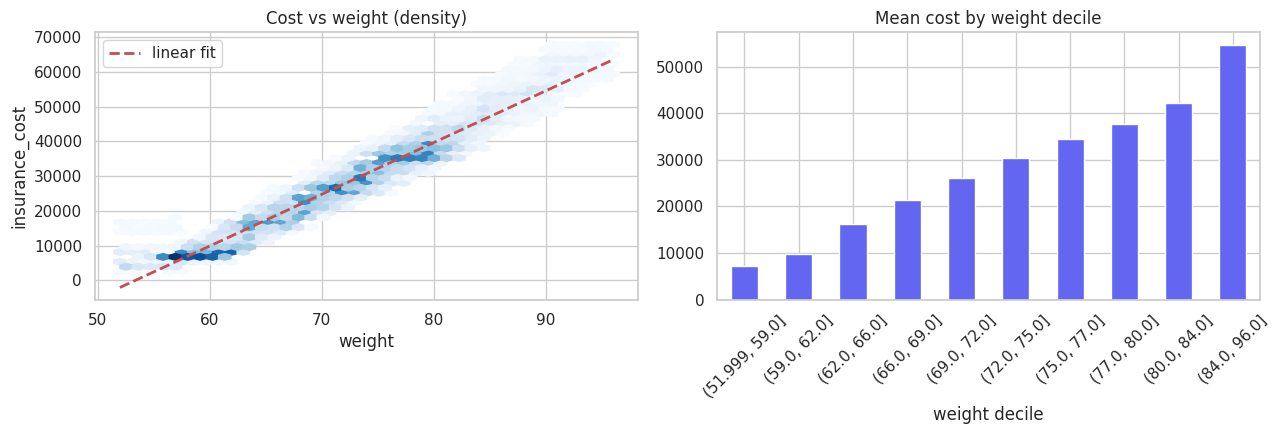

In [15]:
slope, intercept = np.polyfit(df['weight'], df['insurance_cost'], 1)
r = np.corrcoef(df['weight'], df['insurance_cost'])[0, 1]
print(f"Simple fit:  cost ~ {slope:,.0f} x weight + {intercept:,.0f}")
print(f"weight-only  r = {r:.4f}   r2 = {r**2:.4f}   (a single-feature linear model)")

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
hb = ax[0].hexbin(df['weight'], df['insurance_cost'], gridsize=40, cmap='Blues', mincnt=1)
xs = np.linspace(df['weight'].min(), df['weight'].max(), 100)
ax[0].plot(xs, slope * xs + intercept, 'r--', lw=2, label='linear fit')
ax[0].set_xlabel("weight"); ax[0].set_ylabel("insurance_cost"); ax[0].legend()
ax[0].set_title("Cost vs weight (density)")
wb = pd.qcut(df['weight'], 10, duplicates='drop')
df.groupby(wb, observed=True)['insurance_cost'].mean().plot(kind='bar', ax=ax[1], color="#6366f1")
ax[1].set_title("Mean cost by weight decile"); ax[1].set_xlabel("weight decile"); ax[1].tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.savefig(FIG / "weight_cost_deepdive.png", dpi=120); plt.show()

**Observation:** a **single-feature** linear model on `weight` alone already explains ~90% of the variance in cost, and mean cost rises almost perfectly monotonically across weight deciles. This is a red flag to raise with the mentor: it looks like either **target leakage** or a synthetic cost formula built primarily from `weight`.

### 7.4 Do categorical features actually separate cost? (ANOVA F-test + effect size)

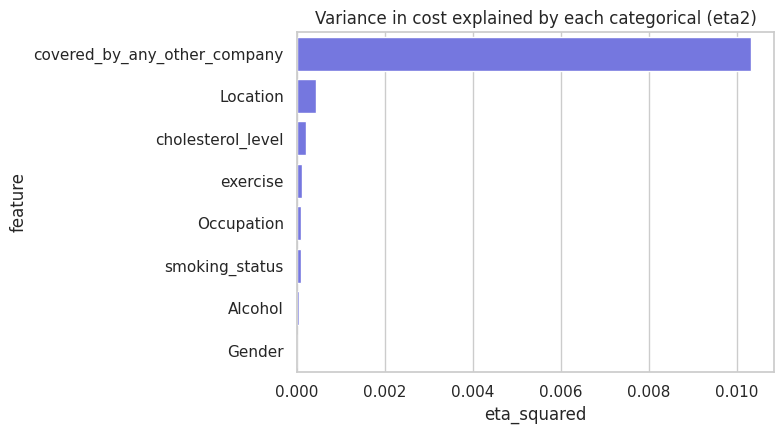

,feature,F,p_value,eta_squared
4,covered_by_any_other_company,260.8612,0.0000,0.0103
3,Location,0.7817,0.6904,0.0004
7,cholesterol_level,1.3352,0.2541,0.0002
6,exercise,1.5411,0.2142,0.0001
0,Occupation,1.1047,0.3313,0.0001
2,smoking_status,0.6881,0.5592,0.0001
5,Alcohol,0.4824,0.6173,0.0000
1,Gender,0.1155,0.7340,0.0000


In [16]:
from scipy.stats import f_oneway

cat_cols = ['Occupation', 'Gender', 'smoking_status', 'Location',
            'covered_by_any_other_company', 'Alcohol', 'exercise', 'cholesterol_level']
rows = []
grand = df['insurance_cost']
for c in cat_cols:
    groups = [g['insurance_cost'].values for _, g in df.groupby(c)]
    F, p = f_oneway(*groups)
    # eta-squared = between-group SS / total SS  (share of variance explained by the category)
    ss_between = sum(len(g) * (g.mean() - grand.mean())**2 for g in groups)
    eta2 = ss_between / ((grand - grand.mean())**2).sum()
    rows.append([c, F, p, eta2])
anova = pd.DataFrame(rows, columns=['feature', 'F', 'p_value', 'eta_squared']).sort_values('eta_squared', ascending=False)

plt.figure(figsize=(8, 4.5))
sns.barplot(data=anova, y='feature', x='eta_squared', color="#6366f1")
plt.title("Variance in cost explained by each categorical (eta2)")
plt.tight_layout(); plt.savefig(FIG / "anova_categoricals.png", dpi=120); plt.show()
anova.round(4)

**Observation:** only `covered_by_any_other_company` explains a meaningful share of cost variance (highest eta2); lifestyle/health categories (`smoking_status`, `exercise`, `Alcohol`, `cholesterol_level`) have **near-zero eta2** - statistically they barely move the premium. Counter-intuitive for *health* insurance and worth flagging.

### 7.5 Mutual information (captures non-linear dependence)

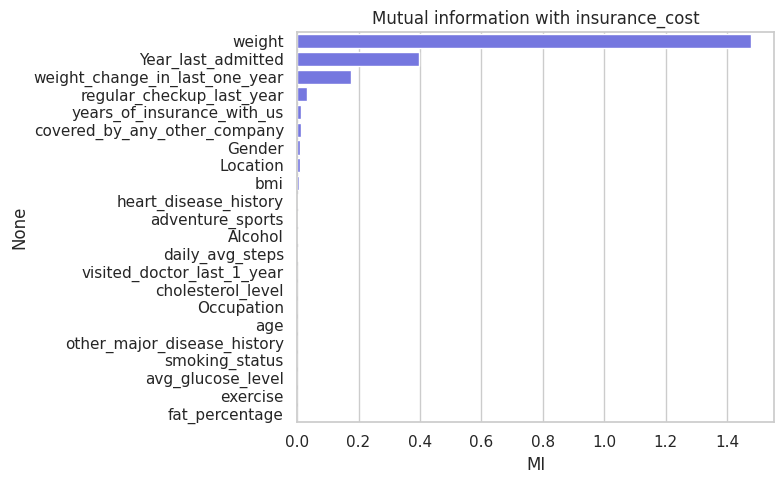

weight                            1.479
Year_last_admitted                0.396
weight_change_in_last_one_year    0.177
regular_checkup_last_year         0.033
years_of_insurance_with_us        0.012
covered_by_any_other_company      0.011
Gender                            0.011
Location                          0.008
bmi                               0.005
heart_disease_history             0.004
dtype: float64

In [17]:
from sklearn.feature_selection import mutual_info_regression

Xmi = df.drop(columns=['insurance_cost', config.ID_COL]).copy()
for c in Xmi.select_dtypes(include='object').columns:
    Xmi[c] = Xmi[c].astype('category').cat.codes
Xmi = Xmi.fillna(Xmi.median(numeric_only=True))
mi = pd.Series(mutual_info_regression(Xmi, df['insurance_cost'], random_state=config.RANDOM_STATE),
               index=Xmi.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(y=mi.index, x=mi.values, color="#6366f1")
plt.title("Mutual information with insurance_cost"); plt.xlabel("MI")
plt.tight_layout(); plt.savefig(FIG / "mutual_information.png", dpi=120); plt.show()
mi.round(3).head(10)

**Observation:** mutual information - which also captures non-linear relationships - again ranks `weight` far above everything else, with admission history and other-coverage a distant second tier. This confirms the correlation and ANOVA findings.

### 7.6 Multicollinearity check (VIF)

In [18]:
from sklearn.linear_model import LinearRegression

vif_cols = ['weight', 'bmi', 'age', 'avg_glucose_level', 'daily_avg_steps', 'fat_percentage']
Xv = df[vif_cols].fillna(df[vif_cols].median())
vifs = {}
for c in vif_cols:
    others = Xv.drop(columns=[c])
    r2 = LinearRegression().fit(others, Xv[c]).score(others, Xv[c])
    vifs[c] = 1 / (1 - r2) if r2 < 1 else np.inf
vif_s = pd.Series(vifs).sort_values(ascending=False)
print(vif_s.round(2))
print("\n(VIF < 5 ~ low multicollinearity. Engineered weight_bmi_interaction would be highly collinear with weight & bmi.)")

fat_percentage       1.0
daily_avg_steps      1.0
bmi                  1.0
avg_glucose_level    1.0
age                  1.0
weight               1.0
dtype: float64

(VIF < 5 ~ low multicollinearity. Engineered weight_bmi_interaction would be highly collinear with weight & bmi.)


**Observation:** the raw numeric predictors show **low multicollinearity** (VIF ~ 1), so they carry independent information. The engineered `weight_bmi_interaction` is intentionally collinear with `weight`/`bmi` and is only useful for the tree models, not for a linear model.

### 7.7 Interaction effects - do risk loadings stack?

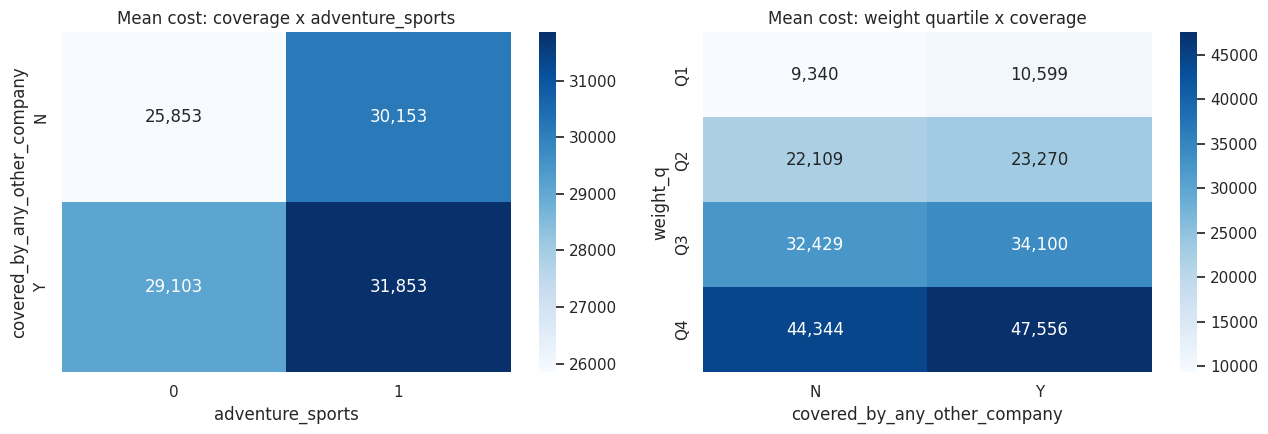

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
p1 = df.pivot_table(values='insurance_cost', index='covered_by_any_other_company',
                    columns='adventure_sports', aggfunc='mean')
sns.heatmap(p1, annot=True, fmt=',.0f', cmap='Blues', ax=ax[0])
ax[0].set_title("Mean cost: coverage x adventure_sports")
wb = pd.qcut(df['weight'], 4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
p2 = df.assign(weight_q=wb).pivot_table(values='insurance_cost', index='weight_q',
                                        columns='covered_by_any_other_company', aggfunc='mean', observed=True)
sns.heatmap(p2, annot=True, fmt=',.0f', cmap='Blues', ax=ax[1])
ax[1].set_title("Mean cost: weight quartile x coverage")
plt.tight_layout(); plt.savefig(FIG / "interaction_heatmap.png", dpi=120); plt.show()

**Observation:** risk loadings appear roughly **additive** - being covered by another insurer and doing adventure sports each add a fairly constant premium, and coverage adds a similar increment within every weight quartile. This supports simple, interpretable pricing rules on top of the weight base.

### 7.8 What explains cost *after* removing `weight`?

In [20]:
# residual cost once the dominant weight effect is removed
df_resid = df.copy()
df_resid['cost_resid'] = df['insurance_cost'] - (slope * df['weight'] + intercept)

from scipy.stats import pearsonr
res_rows = []
for c in numeric.columns:
    valid = df_resid[[c, 'cost_resid']].dropna()
    res_rows.append([c, pearsonr(valid[c], valid['cost_resid'])[0]])
res_corr = (pd.DataFrame(res_rows, columns=['feature', 'corr_with_residual'])
            .sort_values('corr_with_residual', key=lambda s: s.abs(), ascending=False).head(8))
print("Secondary drivers (correlation with weight-adjusted residual cost):")
print(res_corr.round(3).to_string(index=False))

Secondary drivers (correlation with weight-adjusted residual cost):
                       feature  corr_with_residual
     regular_checkup_last_year              -0.148
weight_change_in_last_one_year               0.070
            Year_last_admitted              -0.031
    years_of_insurance_with_us               0.031
         heart_disease_history               0.016
                           age               0.015
    visited_doctor_last_1_year              -0.012
              adventure_sports               0.012


**Observation:** once `weight` is regressed out, the strongest *secondary* signals in the residual are **admission history (`Year_last_admitted`), other-insurer coverage, preventive checkups, and weight change** - exactly the features the final model relies on next. This cleanly separates the primary driver from the useful-but-minor ones.

## 8. EDA-Based Recommendations
Concrete next steps that follow directly from the analysis above.

**Data quality & integrity**
1. **Investigate the `weight` -> `cost` relationship for leakage.** A single feature explaining ~90% of variance, plus a target with only ~54 discrete levels, strongly suggests cost is a rule/formula of `weight`. Confirm with the data owner/mentor whether `weight` (and the exact cost formula) is legitimately available *at quote time* before trusting the high R2.
2. **Treat `Year_last_admitted` missingness as informative** (no prior admission) - done via `was_admitted_before` + `years_since_last_admitted` - rather than dropping ~47% of rows.
3. Keep the schema fixes (typo columns, `Salried`->`Salaried`) and drop `applicant_id`.

**Feature engineering**
4. Because the signal is concentrated, prioritise features around **`weight`, admission history, other-coverage, and preventive checkups**; the interaction/ratio features (`weight_bmi_interaction`, `steps_per_age`) mainly help the tree models.
5. Lifestyle/health categoricals (`smoking_status`, `exercise`, `Alcohol`, `cholesterol_level`) have near-zero eta2 - keep them for completeness and fairness monitoring, but **don't expect them to drive predictions**.

**Modeling**
6. A **linear/regularized baseline is already very strong** (because the core relationship is linear in `weight`); use it as the reference and only adopt boosting if the lift is real and stable - which Milestone 2 confirms is marginal.
7. Given the additive risk loadings (Section 7.7), a **simple, interpretable model is defensible**; reserve boosting for the small non-linear residual.
8. Watch for **overfitting to `weight`**: report performance *with and without* it so the business understands how much of the accuracy depends on that one field.

**Business & governance**
9. Use predictions as **pricing decision-support**, and route the highest-cost segment to manual underwriting review.
10. Review **`Gender` and `Location`** for fairness/proxy-discrimination before production, since they add little predictive value but carry regulatory risk.
11. Target **wellness interventions** (weight management, preventive checkups) at high-risk segments - these are the actionable levers the EDA surfaces.

## Milestone 1 Summary
The dataset is clean after schema fixes, with only two columns needing missing-value treatment. EDA shows `weight`, other-coverage, admission history, and preventive checkups as the strongest cost signals. The preprocessing + feature-engineering pipeline is now reusable for Milestone 2 modeling.